# Model Evaluation

## Import Required Libraries

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
from pathlib import Path

import torch
from torchvision import datasets, transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Path
DATA_DIR = Path("../data/raw")

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

# Image Size
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Test Transform
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test Dataset
test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

# Test Loader
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Class Names
class_names = test_dataset.classes

print("=" * 50)
print("Evaluation Dataset")
print("=" * 50)
print("Device      :", device)
print("Classes     :", class_names)
print("Test Images :", len(test_dataset))

Evaluation Dataset
Device      : cpu
Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']
Test Images : 1600


# Load Best Model

In [5]:
# Load EfficientNet-B0 architecture
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

best_model = efficientnet_b0(weights=weights)

num_features = best_model.classifier[1].in_features

best_model.classifier[1] = torch.nn.Linear(
    num_features,
    len(class_names)
)

best_model = best_model.to(device)

## Load Saved Weights

In [6]:
MODEL_PATH = Path("../models/best_efficientnet_b0.pth")

best_model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

best_model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


## Verify the Loaded Model

In [7]:
print("=" * 60)
print("Loaded Model Information")
print("=" * 60)

print(f"Model Architecture : EfficientNet-B0")
print(f"Number of Classes  : {len(class_names)}")
print(f"Device             : {device}")
print(f"Model Path         : {MODEL_PATH}")

Loaded Model Information
Model Architecture : EfficientNet-B0
Number of Classes  : 4
Device             : cpu
Model Path         : ..\models\best_efficientnet_b0.pth


# Generate Predictions on Test Dataset

In [9]:
# Lists to store predictions and ground truth
true_labels = []
predicted_labels = []

# Switch model to evaluation mode
best_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        # Move to device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = best_model(images)

        # Predicted class
        _, preds = torch.max(outputs, 1)

        # Store results
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())

print("Predictions generated successfully!")

Predictions generated successfully!


# Verify Prediction Results

In [10]:
print("=" * 60)
print("Prediction Summary")
print("=" * 60)

print(f"Total Test Samples : {len(true_labels)}")
print(f"Total Predictions  : {len(predicted_labels)}")

print("\nFirst 10 True Labels:")
print(true_labels[:10])

print("\nFirst 10 Predictions:")
print(predicted_labels[:10])

Prediction Summary
Total Test Samples : 1600
Total Predictions  : 1600

First 10 True Labels:
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

First 10 Predictions:
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0)]


## Display Class Mapping

In [11]:
print("=" * 60)
print("Class Mapping")
print("=" * 60)

for index, class_name in enumerate(class_names):
    print(f"{index} → {class_name}")

Class Mapping
0 → glioma
1 → meningioma
2 → notumor
3 → pituitary


# Confusion Matrix

In [12]:
cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix Generated Successfully!")

Confusion Matrix Generated Successfully!


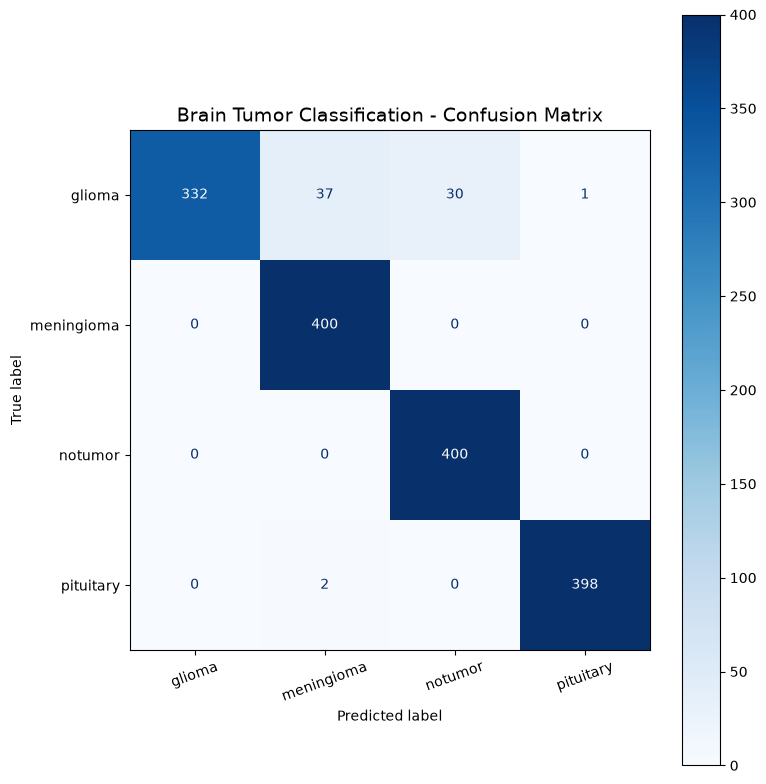

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True
)

plt.title("Brain Tumor Classification - Confusion Matrix", fontsize=14)
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

# Save Confusion Matrix

In [14]:
REPORTS_DIR = Path("../outputs/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

cm_path = REPORTS_DIR / "confusion_matrix.png"

fig.savefig(cm_path, dpi=300, bbox_inches="tight")

print(f"Confusion Matrix saved to:\n{cm_path}")

Confusion Matrix saved to:
..\outputs\reports\confusion_matrix.png


### Display Matrix Values

In [15]:
print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

print(cm)

Confusion Matrix
[[332  37  30   1]
 [  0 400   0   0]
 [  0   0 400   0]
 [  0   2   0 398]]


# Classification Report

In [16]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("Classification Report Generated Successfully!")

Classification Report Generated Successfully!


In [17]:
#Display Report
print("=" * 70)
print("Brain Tumor Classification Report")
print("=" * 70)

print(report_df.round(4))

Brain Tumor Classification Report
              precision  recall  f1-score    support
glioma           1.0000  0.8300    0.9071   400.0000
meningioma       0.9112  1.0000    0.9535   400.0000
notumor          0.9302  1.0000    0.9639   400.0000
pituitary        0.9975  0.9950    0.9962   400.0000
accuracy         0.9562  0.9562    0.9562     0.9562
macro avg        0.9597  0.9562    0.9552  1600.0000
weighted avg     0.9597  0.9562    0.9552  1600.0000


In [18]:
REPORTS_DIR = Path("../outputs/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

csv_path = REPORTS_DIR / "classification_report.csv"

report_df.to_csv(csv_path)

print(f"CSV saved to:\n{csv_path}")

CSV saved to:
..\outputs\reports\classification_report.csv


In [19]:
text_report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)

txt_path = REPORTS_DIR / "classification_report.txt"

with open(txt_path, "w") as file:
    file.write(text_report)

print(f"Text report saved to:\n{txt_path}")

Text report saved to:
..\outputs\reports\classification_report.txt


In [20]:
print("=" * 70)
print("Classification Report")
print("=" * 70)

print(text_report)

Classification Report
              precision    recall  f1-score   support

      glioma       1.00      0.83      0.91       400
  meningioma       0.91      1.00      0.95       400
     notumor       0.93      1.00      0.96       400
   pituitary       1.00      0.99      1.00       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



# Overall Performance Metrics

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [23]:
#Calculate Metrics

accuracy = accuracy_score(true_labels, predicted_labels)

precision_macro = precision_score(
    true_labels,
    predicted_labels,
    average="macro"
)

recall_macro = recall_score(
    true_labels,
    predicted_labels,
    average="macro"
)

f1_macro = f1_score(
    true_labels,
    predicted_labels,
    average="macro"
)

precision_weighted = precision_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

recall_weighted = recall_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

f1_weighted = f1_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

print("Overall metrics calculated successfully!")

Overall metrics calculated successfully!


In [24]:
#Display Metrics

print("=" * 70)
print("Brain Tumor Classification - Overall Performance")
print("=" * 70)

print(f"Accuracy             : {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nMacro Average")
print(f"Precision            : {precision_macro:.4f}")
print(f"Recall               : {recall_macro:.4f}")
print(f"F1-Score             : {f1_macro:.4f}")

print("\nWeighted Average")
print(f"Precision            : {precision_weighted:.4f}")
print(f"Recall               : {recall_weighted:.4f}")
print(f"F1-Score             : {f1_weighted:.4f}")

Brain Tumor Classification - Overall Performance
Accuracy             : 0.9563 (95.62%)

Macro Average
Precision            : 0.9597
Recall               : 0.9563
F1-Score             : 0.9552

Weighted Average
Precision            : 0.9597
Recall               : 0.9563
F1-Score             : 0.9552


### Save Metrics

In [25]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],
    "Value": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

metrics_path = REPORTS_DIR / "overall_metrics.csv"

metrics_df.to_csv(metrics_path, index=False)

print(f"Overall metrics saved to:\n{metrics_path}")

Overall metrics saved to:
..\outputs\reports\overall_metrics.csv


In [26]:
metrics_df

,Metric,Value
0,Accuracy,0.956250
1,Macro Precision,0.959722
2,Macro Recall,0.956250
3,Macro F1-Score,0.955180
4,Weighted Precision,0.959722
5,Weighted Recall,0.956250
6,Weighted F1-Score,0.955180


In [28]:
train_losses = [
    0.4119,
    0.1246,
    0.0714,
    0.0501,
    0.0407,
    0.0251,
    0.0267,
    0.0163
]

train_accuracies = [
    87.79,
    95.86,
    97.57,
    98.36,
    98.73,
    99.20,
    99.20,
    99.57
]

val_losses = [
    0.2580,
    0.2301,
    0.2292,
    0.2323,
    0.2425,
    0.2823,
    0.2681,
    0.2713
]

val_accuracies = [
    92.31,
    93.62,
    94.81,
    95.31,
    95.62,
    95.44,
    95.50,
    95.56
]

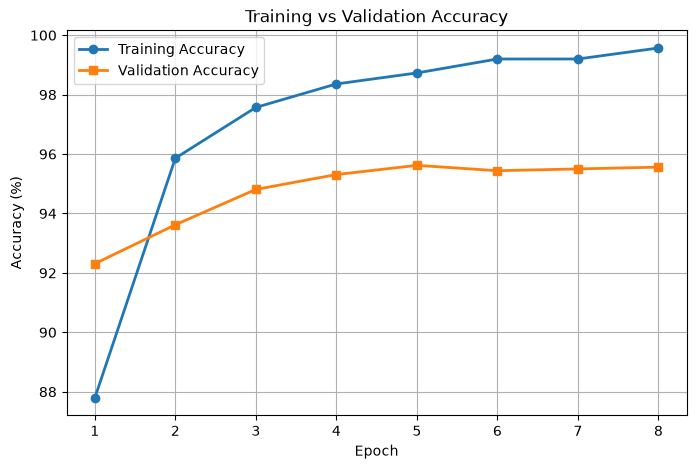

In [29]:
REPORTS_DIR = Path("../outputs/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(train_accuracies, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(val_accuracies, marker="s", linewidth=2, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(len(train_accuracies)), range(1, len(train_accuracies)+1))

plt.grid(True)
plt.legend()

plt.savefig(REPORTS_DIR / "accuracy_curve.png", dpi=300, bbox_inches="tight")

plt.show()

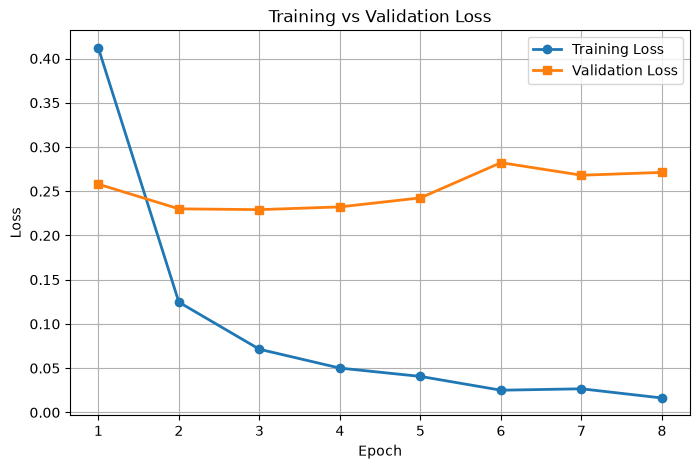

In [30]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker="o", linewidth=2, label="Training Loss")
plt.plot(val_losses, marker="s", linewidth=2, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(len(train_losses)), range(1, len(train_losses)+1))

plt.grid(True)
plt.legend()

plt.savefig(REPORTS_DIR / "loss_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [33]:
history_df = pd.DataFrame({
    "Epoch": range(1, len(train_losses) + 1),
    "Train Loss": train_losses,
    "Validation Loss": val_losses,
    "Train Accuracy": train_accuracies,
    "Validation Accuracy": val_accuracies
})

history_df

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.4119,0.2580,87.79,92.31
1,2,0.1246,0.2301,95.86,93.62
2,3,0.0714,0.2292,97.57,94.81
3,4,0.0501,0.2323,98.36,95.31
4,5,0.0407,0.2425,98.73,95.62
5,6,0.0251,0.2823,99.20,95.44
6,7,0.0267,0.2681,99.20,95.50
7,8,0.0163,0.2713,99.57,95.56


# saving the history as CSV

In [ ]:
import pandas as pd

history_df = pd.DataFrame({
    "Epoch": range(1, len(train_losses)+1),
    "Train Loss": train_losses,
    "Validation Loss": val_losses,
    "Train Accuracy": train_accuracies,
    "Validation Accuracy": val_accuracies
})

history_df.to_csv(REPORTS_DIR / "training_history.csv", index=False)

history_df

# Model Evaluation Summary

In [34]:
import json

evaluation_summary = {
    "Model": "EfficientNet-B0",
    "Dataset": "Brain Tumor MRI Dataset",
    "Number of Classes": len(class_names),
    "Classes": class_names,
    "Best Validation Accuracy (%)": round(accuracy * 100, 2),
    "Macro Precision": round(precision_macro, 4),
    "Macro Recall": round(recall_macro, 4),
    "Macro F1-Score": round(f1_macro, 4),
    "Weighted Precision": round(precision_weighted, 4),
    "Weighted Recall": round(recall_weighted, 4),
    "Weighted F1-Score": round(f1_weighted, 4)
}

In [35]:
print("=" * 70)
print("Brain Tumor AI Model Evaluation Summary")
print("=" * 70)

for key, value in evaluation_summary.items():
    print(f"{key:<30}: {value}")

Brain Tumor AI Model Evaluation Summary
Model                         : EfficientNet-B0
Dataset                       : Brain Tumor MRI Dataset
Number of Classes             : 4
Classes                       : ['glioma', 'meningioma', 'notumor', 'pituitary']
Best Validation Accuracy (%)  : 95.62
Macro Precision               : 0.9597
Macro Recall                  : 0.9563
Macro F1-Score                : 0.9552
Weighted Precision            : 0.9597
Weighted Recall               : 0.9563
Weighted F1-Score             : 0.9552


In [36]:
json_path = REPORTS_DIR / "evaluation_summary.json"

with open(json_path, "w") as file:
    json.dump(evaluation_summary, file, indent=4)

print(f"JSON saved to:\n{json_path}")

JSON saved to:
..\outputs\reports\evaluation_summary.json


In [37]:
txt_path = REPORTS_DIR / "evaluation_summary.txt"

with open(txt_path, "w") as file:
    file.write("Brain Tumor AI Model Evaluation Summary\n")
    file.write("=" * 50 + "\n\n")

    for key, value in evaluation_summary.items():
        file.write(f"{key}: {value}\n")

print(f"Text summary saved to:\n{txt_path}")

Text summary saved to:
..\outputs\reports\evaluation_summary.txt
